In [1]:
# --- Setup: Drive mount + dataset onto Colab's local disk (run once per session) ---
import os, sys, time, zipfile
from google.colab import drive
drive.mount("/content/drive")

DATA = "/content/data"
if not os.path.isdir(DATA):
    t = time.time()
    with zipfile.ZipFile("/content/drive/MyDrive/data.zip") as z:
        z.extractall("/content")
    print(f"unzipped to {DATA} in {time.time() - t:.0f}s")

sys.path.append(f"{DATA}/scripts")
from load_dataset import Dataset

ds = Dataset(DATA)
print(f"camera: {len(ds.camera)} frames | gt: {len(ds.gt)} poses | "
      f"span: {(ds.gt.t_ns.iloc[-1] - ds.gt.t_ns.iloc[0]) / 1e9:.1f} s | "
      f"images on disk: {len(os.listdir(f'{DATA}/camera/images'))}")

Mounted at /content/drive
unzipped to /content/data in 9s
camera: 3465 frames | gt: 1004 poses | span: 116.6 s | images on disk: 3465


# 1 · The experiment at a glance

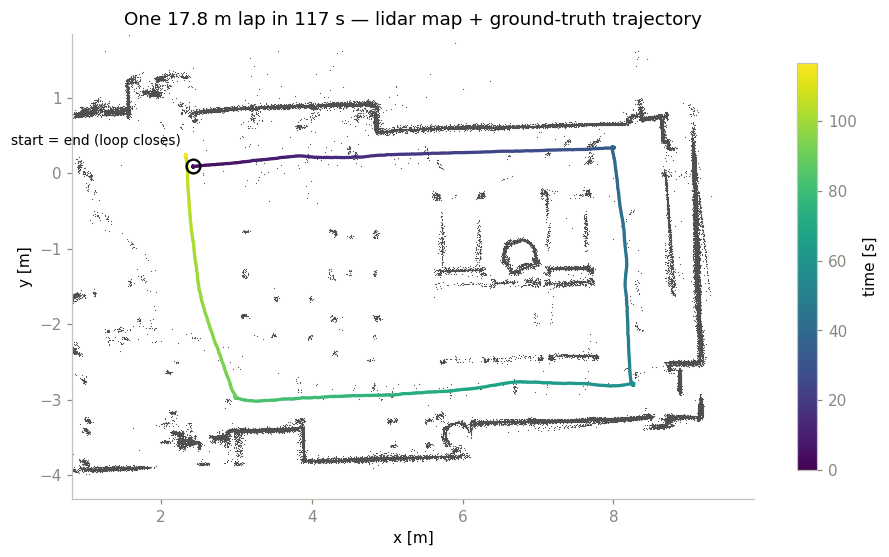

In [2]:
# Where: the ground-truth lap on the lidar map
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c3c2b7", "xtick.color": "#898781",
                     "ytick.color": "#898781", "grid.color": "#e1e0d9",
                     "grid.linewidth": 0.6})

mp = np.load(f"{DATA}/ground_truth/map_points.npz")["xy"]
tg = (ds.gt.t_ns - ds.gt.t_ns.iloc[0]) / 1e9

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(*mp.T, s=0.6, c="0.3", lw=0, rasterized=True)
sc = ax.scatter(ds.gt.x, ds.gt.y, c=tg, s=5, cmap="viridis", lw=0, zorder=3)
ax.plot(ds.gt.x.iloc[0], ds.gt.y.iloc[0], "o", ms=9, mfc="none", mec="k", mew=1.5, zorder=5)
ax.annotate("start = end (loop closes)", xy=(ds.gt.x.iloc[0], ds.gt.y.iloc[0]),
            xytext=(-8, 14), textcoords="offset points", fontsize=9, ha="right")
ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_xlim(ds.gt.x.min() - 1.5, ds.gt.x.max() + 1.6)
ax.set_ylim(ds.gt.y.min() - 1.3, ds.gt.y.max() + 1.5)
fig.colorbar(sc, ax=ax, label="time [s]", shrink=0.8)
ax.set_title("One 17.8 m lap in 117 s — lidar map + ground-truth trajectory")
plt.show()

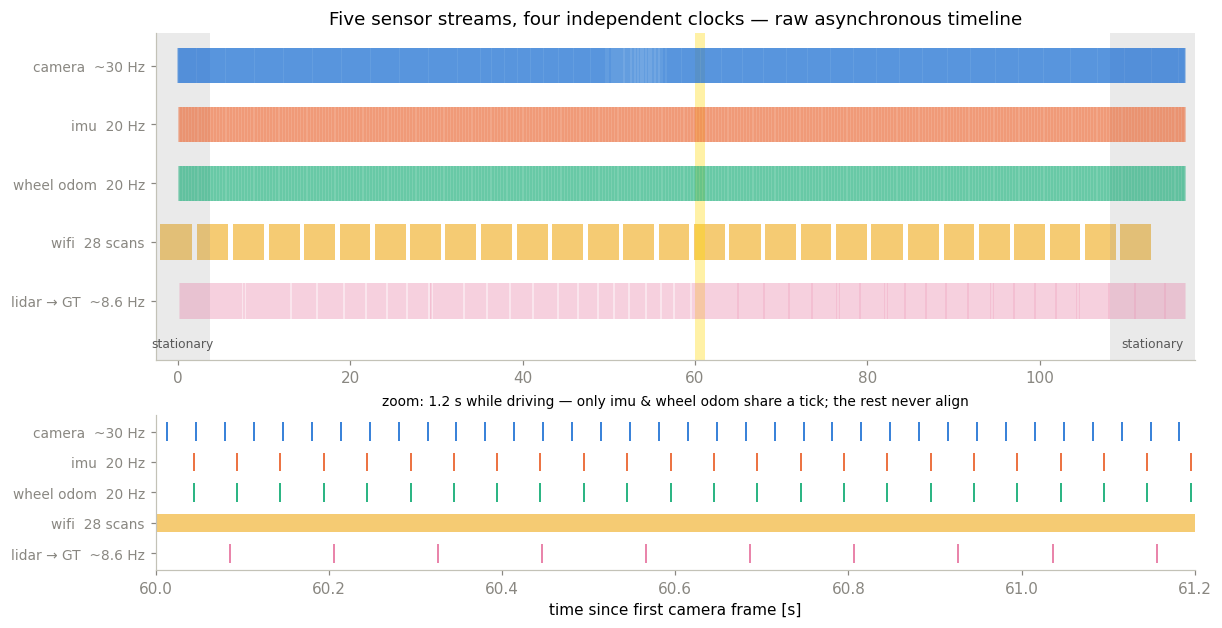

In [3]:
# When: five async streams on one clock axis
t0 = int(ds.camera.t_ns.iloc[0])
sec = lambda s: (np.asarray(s, dtype=np.int64) - t0) / 1e9
cam_t, imu_t, odo_t, gt_t = sec(ds.camera.t_ns), sec(ds.imu.t_ns), sec(ds.odom.t_ns), sec(ds.gt.t_ns)
wf = ds.wifi.groupby("scan_idx").agg(a=("t_start_ns", "first"), b=("t_end_ns", "first"))
w0, w1 = sec(wf.a), sec(wf.b)

v = np.hypot(np.diff(ds.gt.x), np.diff(ds.gt.y)) / np.diff(gt_t)
mv = np.convolve(v, np.ones(9) / 9, "same") > 0.03          # smoothed |v| vs GT noise floor
tA, tB = gt_t[np.argmax(mv)], gt_t[len(mv) - np.argmax(mv[::-1])]

rows = [("camera  ~30 Hz", cam_t, "#2a78d6"), ("imu  20 Hz", imu_t, "#eb6834"),
        ("wheel odom  20 Hz", odo_t, "#1baf7a"), ("wifi  28 scans", None, "#eda100"),
        ("lidar → GT  ~8.6 Hz", gt_t, "#e87ba4")]

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.6), height_ratios=[2.1, 1],
                             constrained_layout=True)
Z0, Z1 = 60.0, 61.2
for ax, lw_ in ((a1, 0.25), (a2, 1.2)):
    for i, (name, tt, c) in enumerate(rows):
        y = len(rows) - 1 - i
        if tt is None:
            ax.broken_barh(list(zip(w0, w1 - w0)), (y - 0.3, 0.6), color=c, alpha=0.55, lw=0)
        else:
            ax.eventplot(tt, lineoffsets=y, linelengths=0.6, colors=c, lw=lw_)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows][::-1], fontsize=9)
    ax.set_ylim(-0.55, len(rows) - 0.45)
a1.set_ylim(-1.0, len(rows) - 0.45)
for (ta, tb, lab) in ((-2.6, tA, "stationary"), (tB, 118, "stationary")):
    a1.axvspan(ta, tb, color="0.55", alpha=0.18, lw=0)
    a1.text((max(ta, -2.6) + min(tb, 118)) / 2, -0.62, lab, ha="center", va="top",
            fontsize=8, color="0.35")
a1.axvspan(Z0, Z1, color="gold", alpha=0.35, lw=0)
a1.set_xlim(-2.6, 118)
a1.set_title("Five sensor streams, four independent clocks — raw asynchronous timeline")
a2.set_xlim(Z0, Z1)
a2.set_xlabel("time since first camera frame [s]")
a2.set_title("zoom: 1.2 s while driving — only imu & wheel odom share a tick; "
             "the rest never align", fontsize=9)
plt.show()

# 2 · Camera

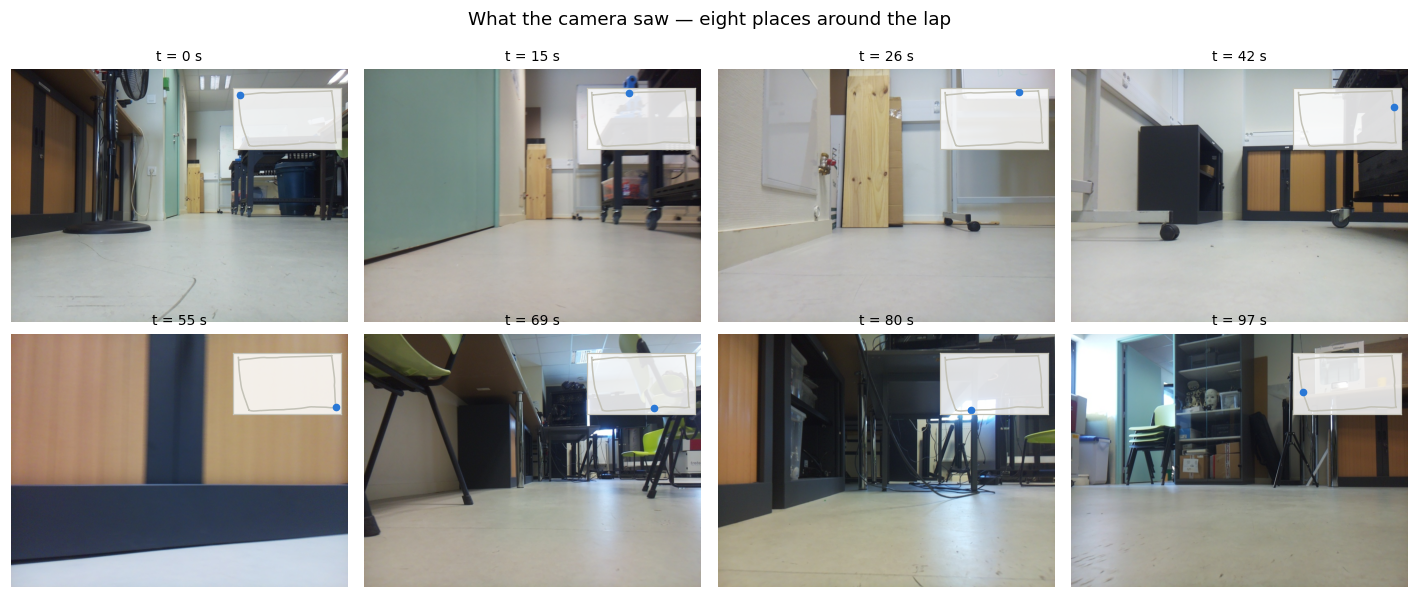

In [4]:
# Eight frames evenly spaced along the path, each located on a mini-map
from PIL import Image
CAM = "#2a78d6"
d = np.hypot(np.diff(ds.camera.x), np.diff(ds.camera.y))
s = np.concatenate([[0.0], np.cumsum(d)])
idx = np.searchsorted(s, np.linspace(0, s[-1], 9)[:-1])

fig, axes = plt.subplots(2, 4, figsize=(13, 5.4))
for ax, k in zip(axes.ravel(), idx):
    ax.imshow(Image.open(f"{DATA}/camera/images/{ds.camera.filename.iloc[k]}"))
    ax.set_title(f"t = {cam_t[k]:.0f} s", fontsize=9)
    ax.axis("off")
    ia = ax.inset_axes([0.66, 0.63, 0.32, 0.35])
    ia.patch.set_alpha(0.85)
    ia.plot(ds.gt.x, ds.gt.y, c="#c3c2b7", lw=1)
    ia.plot(ds.camera.x.iloc[k], ds.camera.y.iloc[k], "o", c=CAM, ms=4)
    ia.set_aspect("equal"); ia.set_xticks([]); ia.set_yticks([])
    for sp in ia.spines.values():
        sp.set_visible(True); sp.set_edgecolor("#c3c2b7")
fig.suptitle("What the camera saw — eight places around the lap", y=1.0)
fig.tight_layout()
plt.show()

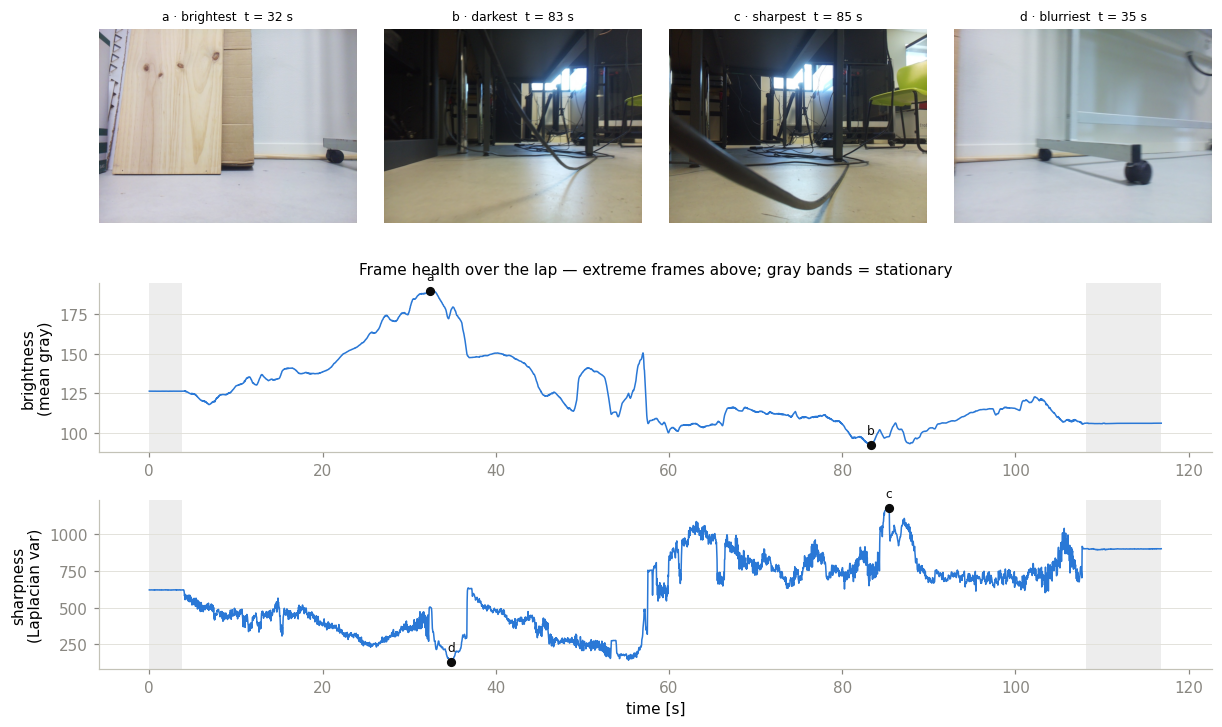

In [5]:
# Sweep all 3465 frames at 1/4 scale (grayscale) -> health traces + extreme frames
import scipy.ndimage as ndi
G = np.empty((len(ds.camera), 154, 205), np.uint8)
for i, fn in enumerate(ds.camera.filename):
    im = Image.open(f"{DATA}/camera/images/{fn}")
    im.draft("L", (205, 154))
    G[i] = np.asarray(im.convert("L").resize((205, 154)))
bright = G.mean((1, 2))
sharp = np.array([ndi.laplace(g.astype(np.float32)).var() for g in G])
frame = lambda k: Image.open(f"{DATA}/camera/images/{ds.camera.filename.iloc[k]}")

picks = [("brightest", np.argmax(bright)), ("darkest", np.argmin(bright)),
         ("sharpest", np.argmax(sharp)), ("blurriest", np.argmin(sharp))]
fig = plt.figure(figsize=(11, 6.6), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1.5, 1, 1])
b1 = fig.add_subplot(gs[1, :]); b2 = fig.add_subplot(gs[2, :], sharex=b1)
for j, (lab, k) in enumerate(picks):
    ta = fig.add_subplot(gs[0, j])
    ta.imshow(frame(k)); ta.axis("off")
    ta.set_title(f"{'abcd'[j]} · {lab}  t = {cam_t[k]:.0f} s", fontsize=8)
    tr, val = (b1, bright[k]) if j < 2 else (b2, sharp[k])
    tr.plot(cam_t[k], val, "o", ms=5, c="#0b0b0b", zorder=5)
    tr.annotate("abcd"[j], (cam_t[k], val), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8, color="#0b0b0b")
b1.plot(cam_t, bright, c=CAM, lw=1.0); b1.set_ylabel("brightness\n(mean gray)")
b2.plot(cam_t, sharp, c=CAM, lw=1.0); b2.set_ylabel("sharpness\n(Laplacian var)")
b2.set_xlabel("time [s]")
for ax in (b1, b2):
    ax.grid(True, axis="y")
    ax.axvspan(cam_t[0], tA, color="0.55", alpha=0.15, lw=0)
    ax.axvspan(tB, cam_t[-1], color="0.55", alpha=0.15, lw=0)
b1.set_title("Frame health over the lap — extreme frames above; gray bands = stationary",
             fontsize=10)
plt.show()

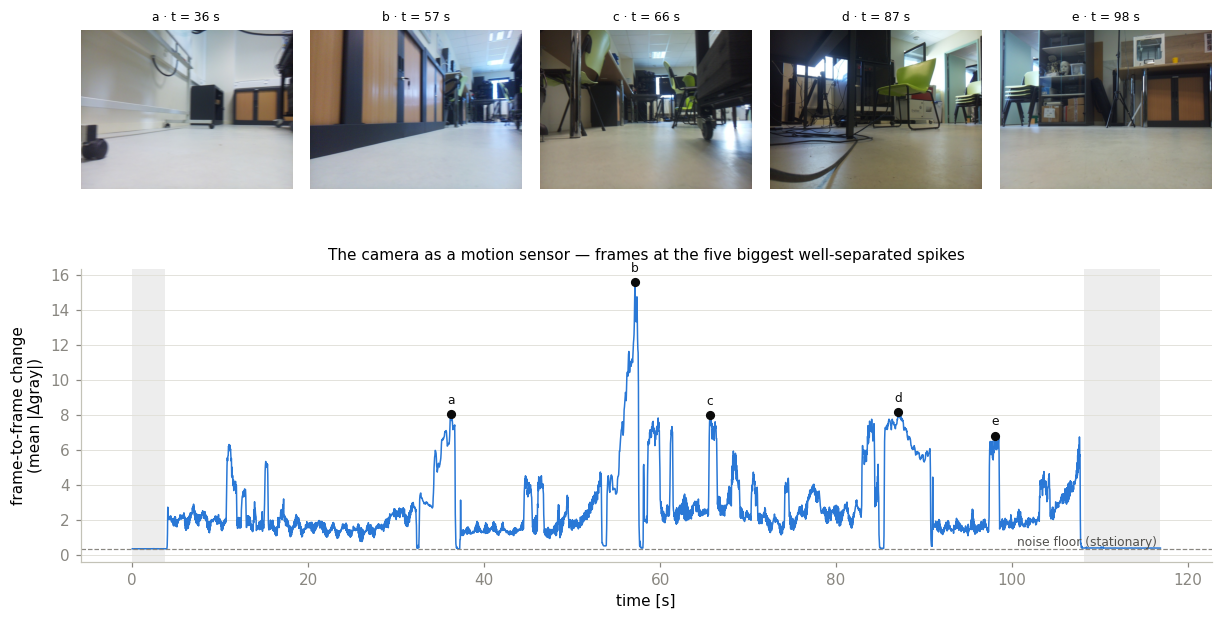

In [6]:
# The camera as a motion sensor: consecutive-frame difference + spike frames
mad = np.abs(np.diff(G.astype(np.int16), axis=0)).mean((1, 2))
floor = np.median(mad[cam_t[1:] < tA])

def spaced_peaks(t, y, k, min_sep):
    picks = []
    for i in np.argsort(y)[::-1]:
        if all(abs(t[i] - t[p]) > min_sep for p in picks):
            picks.append(i)
            if len(picks) == k:
                break
    return sorted(picks)

pk = spaced_peaks(cam_t[1:], mad, 5, min_sep=8.0)
fig = plt.figure(figsize=(11, 5.8), constrained_layout=True)
gs = fig.add_gridspec(2, 5, height_ratios=[1.5, 1.7])
ax = fig.add_subplot(gs[1, :])
for j, i in enumerate(pk):
    ta = fig.add_subplot(gs[0, j])
    ta.imshow(frame(i + 1)); ta.axis("off")
    ta.set_title(f"{'abcde'[j]} · t = {cam_t[i + 1]:.0f} s", fontsize=8)
    ax.plot(cam_t[1:][i], mad[i], "o", ms=5, c="#0b0b0b", zorder=5)
    ax.annotate("abcde"[j], (cam_t[1:][i], mad[i]), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8, color="#0b0b0b")
ax.plot(cam_t[1:], mad, c=CAM, lw=1.0)
ax.grid(True, axis="y")
ax.axhline(floor, c="#898781", lw=0.8, ls="--")
ax.text(cam_t[-1], floor, "noise floor (stationary) ", fontsize=8, color="#52514e",
        va="bottom", ha="right")
ax.axvspan(cam_t[0], tA, color="0.55", alpha=0.15, lw=0)
ax.axvspan(tB, cam_t[-1], color="0.55", alpha=0.15, lw=0)
ax.set_xlabel("time [s]"); ax.set_ylabel("frame-to-frame change\n(mean |Δgray|)")
ax.set_title("The camera as a motion sensor — frames at the five biggest well-separated spikes",
             fontsize=10)
plt.show()

## 2b · Prep — quality census, dedup & provisional split

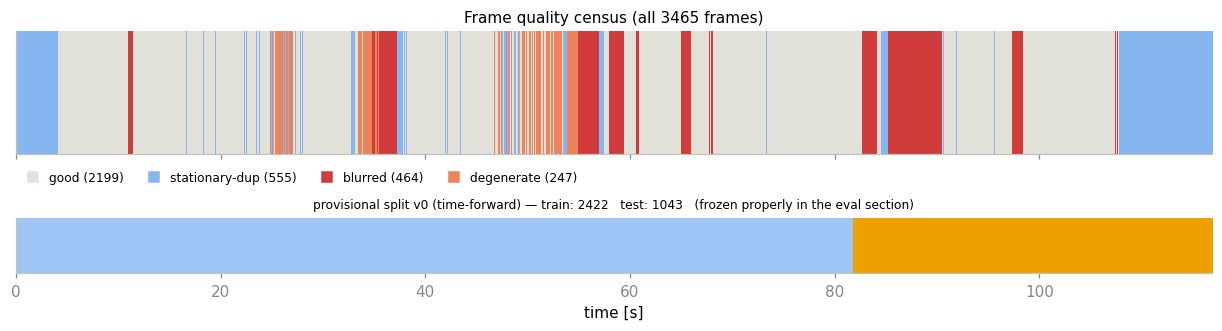

In [7]:
# Classify every frame; build the model-ready camera table `cam`
import collections
from matplotlib.colors import ListedColormap

mad_f = np.concatenate([[mad[0]], mad])                  # align diff signal to frames
stat_seg = (cam_t < tA) | (cam_t > tB)
FLOOR = np.median(mad_f[stat_seg])                       # physics noise floor
THR_STATIC = 3 * FLOOR                                   # "no visible change since previous frame"
THR_BLUR = np.percentile(mad_f[~stat_seg], 85)           # heaviest-motion frames while driving
THR_DEGEN = np.percentile(sharp, 10)                     # lowest-texture close-ups

is_static = mad_f < THR_STATIC; is_static[0] = False
episode_start = is_static & ~np.concatenate([[False], is_static[:-1]])
db_keep = ~is_static | episode_start                     # one representative per resting episode

cls = np.full(len(cam_t), "good", dtype=object)
cls[sharp < THR_DEGEN] = "degenerate"
cls[mad_f > THR_BLUR] = "blurred"
cls[is_static] = "stationary-dup"
t_split = tA + 0.75 * (tB - tA)                          # PROVISIONAL - frozen in the eval section
split = np.where(cam_t < t_split, "train", "test")
cam = ds.camera.assign(t=cam_t, bright=bright, sharp=sharp, mad=mad_f,
                       cls=cls, db_keep=db_keep, split=split)

CLS = [("good", "#e1e0d9"), ("stationary-dup", "#86b6ef"),
       ("blurred", "#d03b3b"), ("degenerate", "#ec835a")]
n = collections.Counter(cls)
strip = np.array([{c: i for i, (c, _) in enumerate(CLS)}[c] for c in cls])[None, :]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 2.9), sharex=True,
                             height_ratios=[1, 0.45], constrained_layout=True)
a1.imshow(strip, aspect="auto", cmap=ListedColormap([c for _, c in CLS]),
          interpolation="nearest", vmin=0, vmax=len(CLS) - 1,
          extent=[cam_t[0], cam_t[-1], 0, 1])
a1.set_yticks([])
a1.set_title("Frame quality census (all 3465 frames)", fontsize=10)
for c, col in CLS:
    a1.plot([], [], "s", c=col, label=f"{c} ({n[c]})")
a1.legend(loc="upper left", bbox_to_anchor=(0, -0.05), ncol=4, frameon=False,
          fontsize=8, handlelength=1.0)
a2.imshow(np.where(split == "train", 0, 1)[None, :], aspect="auto",
          cmap=ListedColormap(["#9ec5f4", "#eda100"]), interpolation="nearest",
          extent=[cam_t[0], cam_t[-1], 0, 1])
a2.set_yticks([])
a2.set_title(f"provisional split v0 (time-forward) — train: {(split=='train').sum()}   "
             f"test: {(split=='test').sum()}   (frozen properly in the eval section)", fontsize=8)
a2.set_xlabel("time [s]")
plt.show()

# 3 · Camera — method roster (official code, smoke runs)

In [8]:
# Shared harness: geometry, undistortion, scoring, and CHECKPOINTING (results persist to Drive)
import os, sys, shutil
import numpy as np
import pandas as pd
import torch
from scipy.spatial.transform import Rotation

RUNS = "/content/runs"; MREPOS = "/content/mrepos"
IMAGES = f"{DATA}/camera/images"
for d in (RUNS, MREPOS): os.makedirs(d, exist_ok=True)

# --- checkpointing: everything a method produces under RUNS is mirrored to Drive; on a fresh
# session it is restored here, and each method cell skips work whose result already exists ---
CKPT = "/content/drive/MyDrive/navlori_ckpt"
DRIVE = os.path.isdir("/content/drive/MyDrive")
if DRIVE:
    os.makedirs(CKPT, exist_ok=True)
    shutil.copytree(CKPT, RUNS, dirs_exist_ok=True)
    print("checkpoint restored:", sorted(os.listdir(RUNS)) or "(empty)")

def keep(path):
    """Mirror a result file/dir (under RUNS) into the Drive checkpoint."""
    if DRIVE and os.path.exists(path):
        dst = os.path.join(CKPT, os.path.relpath(path, RUNS))
        if os.path.isdir(path):
            shutil.copytree(path, dst, dirs_exist_ok=True)
        else:
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(path, dst)

def have(path):
    return os.path.exists(path)

# nominal intrinsics (calib/camera_intrinsics_nominal.yaml — never calibrated, ±1-2%)
FX, FY, CX, CY = 644.1408245617476, 641.7347972317088, 398.5361240843924, 310.506616520141
K_CAM = np.array([[FX, 0, CX], [0, FY, CY], [0, 0, 1]])
DIST = np.array([0.1639958233797625, -0.271840030972792,
                 0.001055841660100477, -0.00166555973740089, 0.0])

# base_footprint -> camera optical frame (calib/extrinsics.yaml, exact values)
T_BASE_CAM = np.eye(4)
T_BASE_CAM[:3, :3] = Rotation.from_quat(
    [-0.4999998415, 0.4996018366, -0.4999998415, 0.5003981634]).as_matrix()
T_BASE_CAM[:3, 3] = [0.076, 0.0, 0.103]

def T_world_base(x, y, yaw):
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s, 0, x], [s, c, 0, y], [0, 0, 1, 0], [0, 0, 0, 1]])

def cam_pose(x, y, yaw):                    # planar base pose -> 4x4 cam-to-world (OpenCV axes)
    return T_world_base(x, y, yaw) @ T_BASE_CAM

def base_pose(T_wc):                        # camera cam-to-world -> (x, y, yaw) of the base
    T = T_wc @ np.linalg.inv(T_BASE_CAM)
    return T[0, 3], T[1, 3], np.arctan2(T[1, 0], T[0, 0])

def undistort_into(filenames, dst_dir, resize=None, names=None):
    import cv2
    os.makedirs(dst_dir, exist_ok=True)
    for i, fn in enumerate(filenames):
        dst = os.path.join(dst_dir, names[i] if names else fn)
        if not os.path.exists(dst):
            img = cv2.undistort(cv2.imread(f"{IMAGES}/{fn}"), K_CAM, DIST)
            if resize: img = cv2.resize(img, resize, interpolation=cv2.INTER_AREA)
            cv2.imwrite(dst, img)

DB = cam[(cam.split == "train") & cam.db_keep].reset_index(drop=True)  # dedup'd train/database
Q = cam[cam.split == "test"].reset_index(drop=True)                    # ALL test frames, unfiltered
PRED = {}

def _score(name, df):
    PRED[name] = j = df.join(cam.set_index("filename"), on="frame", rsuffix="_gt")
    dp = np.hypot(j.x - j.x_gt, j.y - j.y_gt)
    msg = (f"[SMOKE | provisional split] {name}: n={len(j)}  pos err median {dp.median()*100:.1f}"
           f" / mean {dp.mean()*100:.1f} / p90 {dp.quantile(.9)*100:.1f} cm")
    if j.yaw.notna().any():
        dy = np.abs((j.yaw - j.yaw_gt + np.pi) % (2 * np.pi) - np.pi)
        msg += f"  |  yaw median {np.degrees(dy.median()):.2f} deg"
    print(msg)
    for c in ["good", "blurred", "degenerate", "stationary-dup"]:
        m = (j.cls == c).values
        if m.any(): print(f"    {c:15s} n={m.sum():4d}  median {dp[m].median()*100:7.1f} cm")

def smoke(name, frames, x, y, yaw=None):
    df = pd.DataFrame(dict(frame=list(frames), x=x, y=y,
                           yaw=np.nan if yaw is None else yaw))
    os.makedirs(f"{RUNS}/{name}", exist_ok=True)
    df.to_csv(f"{RUNS}/{name}/pred.csv", index=False)
    keep(f"{RUNS}/{name}/pred.csv")
    _score(name, df)

def done(name):
    """True if <name> already has a pred.csv (this session or restored) — reprints its score."""
    p = f"{RUNS}/{name}/pred.csv"
    if os.path.exists(p):
        _score(name, pd.read_csv(p))
        return True
    return False

print(f"database {len(DB)} | queries {len(Q)} | GPU: "
      + (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — enable T4!"))

checkpoint restored: ['ace', 'dpvo', 'gem', 'mst', 'netvlad', 'reloc3r', 'salad']
database 2256 | queries 1043 | GPU: Tesla T4


In [9]:
# B1 · Retrieval floor — frozen ResNet50 (ImageNet weights) + GeM pooling, top-1 lookup (~3 min)
if not done("gem"):
    import torchvision
    from PIL import Image
    from torchvision import transforms as T

    body = torch.nn.Sequential(*list(torchvision.models.resnet50(
        weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).children())[:-2]).eval().cuda()
    tf = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
                    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    @torch.inference_mode()
    def gem_desc(files, p=3.0):
        D = np.zeros((len(files), 2048), np.float32)
        for i in range(0, len(files), 48):
            x = torch.stack([tf(Image.open(f"{IMAGES}/{f}").convert("RGB"))
                             for f in files[i:i + 48]]).cuda()
            with torch.autocast("cuda", torch.float16):
                d = body(x).clamp(min=1e-6).pow(p).mean((-2, -1)).pow(1 / p).float()   # GeM pool
            D[i:i + len(x)] = torch.nn.functional.normalize(d, dim=1).cpu().numpy()
        return D

    Ddb, Dq = gem_desc(list(DB.filename)), gem_desc(list(Q.filename))
    nn = (Dq @ Ddb.T).argmax(1)                  # cosine similarity (descriptors L2-normalized)
    smoke("gem", Q.filename, DB.x.values[nn], DB.y.values[nn], DB.yaw.values[nn])

[SMOKE | provisional split] gem: n=1043  pos err median 341.1 / mean 284.4 / p90 443.1 cm  |  yaw median 84.55 deg
    good            n= 506  median   289.7 cm
    blurred         n= 238  median   227.7 cm
    stationary-dup  n= 299  median   347.8 cm


In [10]:
# R2b · DINOv2-SALAD (CVPR 2024, serizba/salad @6aede13, GPL-3.0) — official model via torch.hub (~6 min)
if not done("salad"):
    %pip -q install "pytorch-lightning>=2.1,<3" pytorch-metric-learning faiss-cpu prettytable
    from PIL import Image
    from torchvision import transforms as T

    salad = torch.hub.load("serizba/salad:6aede13a3f6c25750bf7fde10209c06cb73060bb",
                           "dinov2_salad", trust_repo=True).eval().cuda()
    tf = T.Compose([T.Resize((322, 322), interpolation=T.InterpolationMode.BILINEAR),
                    T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    @torch.inference_mode()
    def salad_desc(files):
        D = np.zeros((len(files), 8448), np.float32)
        for i in range(0, len(files), 32):
            x = torch.stack([tf(Image.open(f"{IMAGES}/{f}").convert("RGB"))
                             for f in files[i:i + 32]]).cuda()
            with torch.autocast("cuda", torch.float16):
                D[i:i + len(x)] = salad(x).float().cpu().numpy()
        return D

    Ddb, Dq = salad_desc(list(DB.filename)), salad_desc(list(Q.filename))
    nn = (Dq @ Ddb.T).argmax(1)
    smoke("salad", Q.filename, DB.x.values[nn], DB.y.values[nn], DB.yaw.values[nn])

[SMOKE | provisional split] salad: n=1043  pos err median 264.0 / mean 371.8 / p90 664.7 cm  |  yaw median 85.07 deg
    good            n= 506  median   229.1 cm
    blurred         n= 238  median   136.8 cm
    stationary-dup  n= 299  median   664.7 cm


In [11]:
%%bash
# B3 · NetVLAD — official hloc toolbox (cvg/Hierarchical-Localization @c13273b, Apache-2.0)
set -e
[ -f /content/runs/netvlad/pred.csv ] && { echo "netvlad done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/hloc ]; then
  git clone -q --recursive https://github.com/cvg/Hierarchical-Localization.git /content/mrepos/hloc
  cd /content/mrepos/hloc && git checkout -q c13273bd0ecc2917a35910fd843712a1c6243193 \
    && git submodule update -q --init --recursive
fi
pip install -q -e /content/mrepos/hloc

netvlad done — skipping install


In [12]:
# stage db/query symlinks -> official extractor -> top-1 neighbor -> matched frame's pose (~7 min)
if not done("netvlad"):
    import h5py
    for sub, rows in [("db", DB), ("query", Q)]:
        d = f"{RUNS}/netvlad/images/{sub}"; os.makedirs(d, exist_ok=True)
        for fn in rows.filename:
            if not os.path.lexists(f"{d}/{fn}"): os.symlink(f"{IMAGES}/{fn}", f"{d}/{fn}")
    !python -m hloc.extract_features --conf netvlad --image_dir {RUNS}/netvlad/images --export_dir {RUNS}/netvlad --as_half
    with h5py.File(f"{RUNS}/netvlad/global-feats-netvlad.h5", "r") as fd:
        dbn, qn = sorted(fd["db"].keys()), sorted(fd["query"].keys())
        Ddb = np.stack([fd[f"db/{n}"]["global_descriptor"][...] for n in dbn]).astype(np.float32)
        Dq = np.stack([fd[f"query/{n}"]["global_descriptor"][...] for n in qn]).astype(np.float32)
    g = cam.set_index("filename").loc[np.array(dbn)[(Dq @ Ddb.T).argmax(1)]]
    smoke("netvlad", qn, g.x.values, g.y.values, g.yaw.values)

[SMOKE | provisional split] netvlad: n=1043  pos err median 239.6 / mean 362.6 / p90 646.6 cm  |  yaw median 92.79 deg
    good            n= 506  median   234.5 cm
    blurred         n= 238  median    76.0 cm
    stationary-dup  n= 299  median   646.5 cm


In [13]:
%%bash
# B2 · MS-Transformer (ICCV 2021, yolish/multi-scene-pose-transformer @56ca699; authors' code, no license file)
set -e
[ -f /content/runs/mst/pred.csv ] && { echo "mst done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/mst ]; then
  git clone -q https://github.com/yolish/multi-scene-pose-transformer.git /content/mrepos/mst
  cd /content/mrepos/mst && git checkout -q 56ca699fa61ad689f3631231c03608e46c9c7938
fi
pip install -q efficientnet-pytorch==0.7.1

mst done — skipping install


In [14]:
# adapter: our GT -> their 7Scenes-style CSV; then train their entry point unchanged (~30-60 min)
# (skips training if a trained model is already checkpointed)
import json, runpy, types, torchvision.ops, torchvision.ops.misc

os.makedirs(f"{RUNS}/mst", exist_ok=True)
def labels_csv(rows, path, split):                       # poses fed as-is: planar base pose,
    with open(path, "w") as f:                           # scalar-first quaternion from yaw
        f.write("scene,split,seq,img_path,t1,t2,t3,q1,q2,q3,q4\n")
        for r in rows.itertuples():
            f.write(f"myroom,{split},0,{r.filename},{r.x},{r.y},0.0,"
                    f"{np.cos(r.yaw / 2)},0.0,0.0,{np.sin(r.yaw / 2)}\n")
labels_csv(DB, f"{RUNS}/mst/train.csv", "train")
labels_csv(Q, f"{RUNS}/mst/test.csv", "test")
mst_cfg = json.load(open(f"{MREPOS}/mst/7Scenes_config.json")) if os.path.exists(
    f"{MREPOS}/mst/7Scenes_config.json") else json.load(open(f"{RUNS}/mst/config.json"))
mst_cfg["ems-transposenet"]["num_scenes"] = 1
mst_cfg["general"].update(n_workers=2, n_freq_print=100)
json.dump(mst_cfg, open(f"{RUNS}/mst/config.json", "w"), indent=1)
keep(f"{RUNS}/mst/config.json")

if not have(f"{RUNS}/mst/final.pth") and not have(f"{RUNS}/mst/pred.csv"):
    # their repo folders (datasets/, models/, util/) have no __init__.py -> namespace packages,
    # which LOSE to installed packages of the same name (HuggingFace `datasets` on Colab!)
    for pkg in ["datasets", "models", "util"]:
        m = types.ModuleType(pkg)
        m.__path__ = [f"{MREPOS}/mst/{pkg}"]
        sys.modules[pkg] = m
    # two symbols their old-torchvision guard imports but never calls + torch>=2.6 pickle env var
    if not hasattr(torchvision.ops, "_new_empty_tensor"):
        torchvision.ops._new_empty_tensor = lambda x, s: x.new_empty(s)
    if not hasattr(torchvision.ops.misc, "_output_size"):
        torchvision.ops.misc._output_size = lambda d, i, s=None, f=None: []
    os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

    os.chdir(f"{MREPOS}/mst"); sys.path.insert(0, f"{MREPOS}/mst")
    sys.argv = ["main.py", "ems-transposenet", "train", "./models/backbones/efficient-net-b0.pth",
                IMAGES, f"{RUNS}/mst/train.csv", f"{RUNS}/mst/config.json", "--experiment", "myroom"]
    runpy.run_path("main.py", run_name="__main__")       # their official entry point, unchanged
    os.chdir("/content")
    import glob
    ck = max(glob.glob(f"{MREPOS}/mst/out/run_*_final.pth"), key=os.path.getmtime)
    shutil.copy2(ck, f"{RUNS}/mst/final.pth")
    keep(f"{RUNS}/mst/final.pth")
else:
    print("mst: trained model / result already checkpointed — skipping training")

mst: trained model / result already checkpointed — skipping training


In [15]:
# dump per-frame poses (their model + dataset as an unchanged library) and score
if not done("mst"):
    import types
    for pkg in ["datasets", "models", "util"]:           # same namespace pinning as the train cell
        m = types.ModuleType(pkg)
        m.__path__ = [f"{MREPOS}/mst/{pkg}"]
        sys.modules[pkg] = m
    import torchvision.ops, torchvision.ops.misc
    if not hasattr(torchvision.ops, "_new_empty_tensor"):
        torchvision.ops._new_empty_tensor = lambda x, s: x.new_empty(s)
    if not hasattr(torchvision.ops.misc, "_output_size"):
        torchvision.ops.misc._output_size = lambda d, i, s=None, f=None: []
    os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
    from util import utils
    from datasets.CameraPoseDataset import CameraPoseDataset
    from models.pose_regressors import get_model

    config = {**mst_cfg["ems-transposenet"], **mst_cfg["general"]}
    os.chdir(f"{MREPOS}/mst")
    model = get_model("ems-transposenet", "./models/backbones/efficient-net-b0.pth", config).cuda()
    model.load_state_dict(torch.load(f"{RUNS}/mst/final.pth")); model.eval()
    ds_test = CameraPoseDataset(IMAGES, f"{RUNS}/mst/test.csv", utils.test_transforms.get("baseline"))
    P = []
    with torch.no_grad():                                # mirrors their official test path (batch 1, scene=None)
        for mb in torch.utils.data.DataLoader(ds_test, batch_size=1, shuffle=False, num_workers=2):
            for k, v in mb.items(): mb[k] = v.cuda()
            mb["scene"] = None
            P.append(model(mb)["pose"].cpu().numpy())
    P = np.concatenate(P); os.chdir("/content")
    smoke("mst", Q.filename, P[:, 0], P[:, 1], 2 * np.arctan2(P[:, 6], P[:, 3]))

[SMOKE | provisional split] mst: n=1043  pos err median 397.5 / mean 373.8 / p90 528.9 cm  |  yaw median 88.88 deg
    good            n= 506  median   360.4 cm
    blurred         n= 238  median   321.5 cm
    stationary-dup  n= 299  median   447.6 cm


In [16]:
%%bash
# R1 · ACE (CVPR 2023, nianticlabs/ace @e9e90f2, non-commercial) — builds the DSAC* pose solver
set -e
[ -f /content/runs/ace/pred.csv ] && [ -f /content/runs/ace/test_navlori_sanity_s.txt ] \
  && { echo "ace done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/ace ]; then
  git clone -q https://github.com/nianticlabs/ace.git /content/mrepos/ace
  cd /content/mrepos/ace && git checkout -q e9e90f2d02ee92c348bf411a5a60e230af6c315e
fi
python -c "
import pathlib
s = pathlib.Path('/content/mrepos/ace/ace_encoder_pretrained.pt').stat().st_size
assert s == 22278371, f'encoder looks like an LFS pointer: {s} bytes'"
apt-get -qq update && apt-get -qq install -y libopencv-dev > /dev/null
pip install -q pyrender trimesh
# guard must ask for the FUNCTION, not just the module: a failed install can leave an empty
# namespace-package ghost in site-packages that imports fine but contains nothing
cd /content && python -c "import torch, dsacstar; dsacstar.forward_rgb" 2>/dev/null || \
  (pip uninstall -y -q dsacstar 2>/dev/null; \
   cd /content/mrepos/ace/dsacstar && CONDA_PREFIX=/usr pip install -q --no-build-isolation --force-reinstall .)
cd /content && python -c "import torch, dsacstar; dsacstar.forward_rgb; print('dsacstar OK:', dsacstar.__file__)"

ace done — skipping install


In [17]:
# adapter: undistorted frames + 4x4 cam-to-world poses (OpenCV axes) + 3x3 K files, then their train/test (~25 min)
if not done("ace"):
    import runpy
    scene = f"{RUNS}/ace/navlori"
    f_mean = (FX + FY) / 2                               # ACE asserts fx == fy; 0.2% averaging error
    for split, rows in [("train", DB), ("test", Q)]:
        for sub in ["rgb", "poses", "calibration"]:
            os.makedirs(f"{scene}/{split}/{sub}", exist_ok=True)
        undistort_into(list(rows.filename), f"{scene}/{split}/rgb",
                       names=[f"frame-{i:06d}.color.jpg" for i in range(len(rows))])
        for i, r in enumerate(rows.itertuples()):
            np.savetxt(f"{scene}/{split}/poses/frame-{i:06d}.pose.txt", cam_pose(r.x, r.y, r.yaw))
            with open(f"{scene}/{split}/calibration/frame-{i:06d}.calibration.txt", "w") as f:
                f.write(f"{f_mean} 0 {CX}\n0 {f_mean} {CY}\n0 0 1\n")
    print("ace scene staged")

    if not have(f"{RUNS}/ace/navlori.pt"):
        # torch>=2.5 removed the LR scheduler's private optimizer._step_count patching that ACE
        # reads to detect fp16-skipped steps; recreate the old semantic (their code untouched)
        _orig_step = torch.optim.AdamW.step
        def _counted_step(self, *a, **k):
            out = _orig_step(self, *a, **k)
            self._step_count = getattr(self, "_step_count", 0) + 1
            return out
        torch.optim.AdamW.step = _counted_step
        torch.optim.AdamW._step_count = 0
        os.chdir(f"{MREPOS}/ace")
        sys.argv = ["train_ace.py", scene, f"{RUNS}/ace/navlori.pt", "--training_buffer_size", "4000000"]
        runpy.run_path("train_ace.py", run_name="__main__")   # their official entry point, unchanged
        torch.optim.AdamW.step = _orig_step
        os.chdir("/content")
        keep(f"{RUNS}/ace/navlori.pt")
    else:
        print("ace: trained head already checkpointed — skipping training")

    !cd {MREPOS}/ace && python test_ace.py {scene} {RUNS}/ace/navlori.pt --session run1

    # their poses file is WORLD-TO-CAM with a qw-first quaternion -> invert, convert to base frame
    recovered = []
    for line in open(f"{RUNS}/ace/poses_navlori_run1.txt"):
        p = line.split()
        T = np.eye(4)
        T[:3, :3] = Rotation.from_quat([float(p[2]), float(p[3]), float(p[4]), float(p[1])]).as_matrix()
        T[:3, 3] = [float(p[5]), float(p[6]), float(p[7])]
        recovered.append((int(p[0][6:12]), *base_pose(np.linalg.inv(T))))
    recovered.sort()
    smoke("ace", Q.filename, [r[1] for r in recovered], [r[2] for r in recovered],
          [r[3] for r in recovered])

[SMOKE | provisional split] ace: n=1043  pos err median 580.0 / mean 660.9 / p90 1349.6 cm  |  yaw median 79.34 deg
    good            n= 506  median   585.3 cm
    blurred         n= 238  median   127.6 cm
    stationary-dup  n= 299  median   872.4 cm


In [18]:
# ACE upper bound: evaluate on every 10th TRAINING view (seen viewpoints) — separates
# "method/pipeline health" from "the split makes novel views impossible"
res = f"{RUNS}/ace/test_navlori_sanity_s.txt"
if not have(res):
    rows = DB.iloc[::10].reset_index(drop=True)
    tst = f"{RUNS}/ace/navlori_sanity/test"
    for sub in ["rgb", "poses", "calibration"]:
        os.makedirs(f"{tst}/{sub}", exist_ok=True)
    undistort_into(list(rows.filename), f"{tst}/rgb",
                   names=[f"frame-{i:06d}.color.jpg" for i in range(len(rows))])
    for i, r in enumerate(rows.itertuples()):
        np.savetxt(f"{tst}/poses/frame-{i:06d}.pose.txt", cam_pose(r.x, r.y, r.yaw))
        with open(f"{tst}/calibration/frame-{i:06d}.calibration.txt", "w") as f:
            f.write(f"{(FX + FY) / 2} 0 {CX}\n0 {(FX + FY) / 2} {CY}\n0 0 1\n")
    !cd {MREPOS}/ace && python test_ace.py {RUNS}/ace/navlori_sanity {RUNS}/ace/navlori.pt --session s
    keep(res)
r_err, t_err, _ = open(res).read().split()
print(f"[SMOKE] ace on SEEN training views: median {float(t_err):.1f} cm / {float(r_err):.2f} deg")

[SMOKE] ace on SEEN training views: median 0.9 cm / 0.23 deg


In [19]:
%%bash
# R2 · Reloc3r-512 (CVPR 2025, ffrivera0/reloc3r @761fac6, CC BY-NC-SA) — pretrained, no scene training
set -e
[ -f /content/runs/reloc3r/pred.csv ] && { echo "reloc3r done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/reloc3r ]; then
  git clone -q --recursive https://github.com/ffrivera0/reloc3r.git /content/mrepos/reloc3r
  cd /content/mrepos/reloc3r && git checkout -q 761fac648e9c21fd7dcda01ab2ccd4fc20058102 \
    && git submodule update -q --init --recursive
fi
pip install -q roma matplotlib tqdm opencv-python scipy einops tensorboard \
  'huggingface-hub[torch]>=0.22' imagesize

reloc3r done — skipping install


In [20]:
# adapter: fake 7Scenes 'heads' tree — EXACTLY 1000 db + 1000 query frames, undistorted AND resized
# to 640x480 (their loader crops around a HARDCODED principal point (320,240): raw 820x616 frames
# would silently lose their right/bottom bands). Then their official eval (~30 min on T4).
if not done("reloc3r"):
    root = f"{RUNS}/reloc3r/7scenes/heads"

    def pick(rows, n):
        return rows.iloc[np.linspace(0, len(rows) - 1, n).round().astype(int)].reset_index(drop=True)

    r3_db, r3_query = pick(DB, 1000), pick(Q, 1000)
    for seq, rows in [("seq-02", r3_db), ("seq-01", r3_query)]:
        undistort_into(list(rows.filename), f"{root}/{seq}", resize=(640, 480),
                       names=[f"frame-{i:06d}.color.png" for i in range(len(rows))])
        for i, r in enumerate(rows.itertuples()):
            np.savetxt(f"{root}/{seq}/frame-{i:06d}.pose.txt", cam_pose(r.x, r.y, r.yaw))
    print("reloc3r scene staged")
    os.makedirs(f"{MREPOS}/reloc3r/data", exist_ok=True)
    !ln -sfn {RUNS}/reloc3r/7scenes {MREPOS}/reloc3r/data/7scenes
    !cd {MREPOS}/reloc3r && python eval_visloc.py --model "Reloc3rRelpose(img_size=512)" \
      --dataset_db "SevenScenesRetrieval(scene='{{}}', split='train')" \
      --dataset_q "SevenScenesRetrieval(scene='{{}}', split='test')" \
      --dataset_relpose "SevenScenesRelpose(scene='{{}}', pair_id={{}}, resolution={{}})" \
      --scene "heads" --topk 10 --batch_size 8 --num_workers 2 --amp 1

[SMOKE | provisional split] reloc3r: n=1000  pos err median 341.4 / mean 372.9 / p90 654.3 cm  |  yaw median 164.76 deg
    good            n= 485  median   312.3 cm
    blurred         n= 228  median    73.4 cm
    stationary-dup  n= 287  median   652.3 cm


In [21]:
# recover absolute poses: their eval only prints medians — re-run their motion averaging over the cached pairs
if not done("reloc3r"):
    sys.path.insert(0, f"{MREPOS}/reloc3r")
    from reloc3r.reloc3r_visloc import Reloc3rVisloc

    va = Reloc3rVisloc()
    cache = f"{MREPOS}/reloc3r/_db-q_pair_info"
    xs, ys, yaws = [], [], []
    for fid in range(1000):
        pdb = [np.loadtxt(f"{cache}/poses_heads_pair-id={k}/seq-01_{fid:06d}_pose-db.txt")
               for k in range(10)]
        pq2 = [np.loadtxt(f"{cache}/poses_heads_pair-id={k}/seq-01_{fid:06d}_pose-q2d.txt")
               for k in range(10)]
        x, y, w = base_pose(va.motion_averaging(pdb, pq2))
        xs.append(x); ys.append(y); yaws.append(w)
    smoke("reloc3r", r3_query.filename, xs, ys, yaws)

[SMOKE | provisional split] reloc3r: n=1000  pos err median 341.4 / mean 372.9 / p90 654.3 cm  |  yaw median 164.76 deg
    good            n= 485  median   312.3 cm
    blurred         n= 228  median    73.4 cm
    stationary-dup  n= 287  median   652.3 cm


In [22]:
%%bash
# R3 · DPVO (NeurIPS 2023, princeton-vl/DPVO @859bbbf, MIT) — own venv: its CUDA ops need torch 2.3.1
# First run ~20-30 min (wheel downloads + CUDA compile); cached afterwards.
set -e
[ -f /content/runs/dpvo/ate_navlori_lc.json ] && { echo "dpvo done — skipping install"; exit 0; }
V=/content/venvs/dpvo
if [ ! -d /content/mrepos/DPVO ]; then
  git clone -q --recursive https://github.com/princeton-vl/DPVO.git /content/mrepos/DPVO
  cd /content/mrepos/DPVO && git checkout -q 859bbbfdac6c6185f345003b3c473901fcd13ace
fi
if [ ! -f $V/ok ]; then
  rm -rf $V                                   # wipe any half-created venv from a failed attempt
  pip install -q virtualenv                   # Colab's python lacks ensurepip (no python3.12-venv);
  virtualenv -q $V                            # virtualenv seeds pip from bundled wheels instead
  $V/bin/pip -q install -U setuptools wheel
  $V/bin/pip -q install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121
  $V/bin/pip -q install numpy==1.26.4 'opencv-python<4.11' evo plyfile yacs tqdm einops \
    numba pypose kornia scipy tensorboard gdown
  $V/bin/pip -q install torch-scatter -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
  cd /content/mrepos/DPVO
  [ -d thirdparty/eigen-3.4.0 ] || (wget -q https://gitlab.com/libeigen/eigen/-/archive/3.4.0/eigen-3.4.0.zip \
     && unzip -qo eigen-3.4.0.zip -d thirdparty)
  TORCH_CUDA_ARCH_LIST="7.5" $V/bin/pip install -q --no-build-isolation .
  [ -f dpvo.pth ] || ($V/bin/gdown -q 1dRqftpImtHbbIPNBIseCv9EvrlHEnjhX -O models.zip && unzip -qo models.zip)
  MPLBACKEND=Agg $V/bin/python -c "from dpvo.dpvo import DPVO; print('DPVO import OK')"
  touch $V/ok
fi

dpvo done — skipping install


In [23]:
# adapter: zero-padded frame symlinks + calib line (fx fy cx cy k1 k2 p1 p2 k3) + camera GT in TUM
# (timestamps = DPVO's output indices); run plain VO + DPV-SLAM loop closure; Sim(3)-align to score
# (monocular VO has arbitrary scale and its own origin — Umeyama alignment with scale is the protocol)
import json
if not have(f"{RUNS}/dpvo/ate_navlori_lc.json"):
    %pip -q install evo
    d = f"{RUNS}/dpvo/frames"; os.makedirs(d, exist_ok=True)
    for i, fn in enumerate(cam.filename):               # ALL 3465 frames — VO wants the full video
        if not os.path.lexists(f"{d}/frame_{i:06d}.jpg"):
            os.symlink(f"{IMAGES}/{fn}", f"{d}/frame_{i:06d}.jpg")
    with open(f"{RUNS}/dpvo/calib.txt", "w") as f:
        f.write(f"{FX} {FY} {CX} {CY} " + " ".join(map(str, DIST)) + "\n")
    with open(f"{RUNS}/dpvo/gt_tum.txt", "w") as f:
        for t, r in enumerate(cam.itertuples()):
            T = cam_pose(r.x, r.y, r.yaw)               # camera trajectory GT (DPVO outputs camera poses)
            qq = Rotation.from_matrix(T[:3, :3]).as_quat()
            f.write(f"{t} {T[0,3]} {T[1,3]} {T[2,3]} {qq[0]} {qq[1]} {qq[2]} {qq[3]}\n")
    V = "/content/venvs/dpvo/bin/python"
    !cd {MREPOS}/DPVO && MPLBACKEND=Agg {V} demo.py --imagedir={RUNS}/dpvo/frames --calib={RUNS}/dpvo/calib.txt \
      --network=dpvo.pth --config=config/default.yaml --stride=1 --name=navlori --save_trajectory
    !cd {MREPOS}/DPVO && MPLBACKEND=Agg {V} demo.py --imagedir={RUNS}/dpvo/frames --calib={RUNS}/dpvo/calib.txt \
      --network=dpvo.pth --config=config/default.yaml --stride=1 --name=navlori_lc --save_trajectory \
      --opts LOOP_CLOSURE True

    from evo.core import sync, metrics
    from evo.tools import file_interface
    gt_traj = file_interface.read_tum_trajectory_file(f"{RUNS}/dpvo/gt_tum.txt")
    for name in ["navlori", "navlori_lc"]:
        shutil.copy2(f"{MREPOS}/DPVO/saved_trajectories/{name}.txt", f"{RUNS}/dpvo/{name}.txt")
        est = file_interface.read_tum_trajectory_file(f"{RUNS}/dpvo/{name}.txt")
        g, e = sync.associate_trajectories(gt_traj, est)
        e.align(g, correct_scale=True)
        ape = metrics.APE(metrics.PoseRelation.translation_part)
        ape.process_data((g, e))
        json.dump({k: float(v) for k, v in ape.get_all_statistics().items()},
                  open(f"{RUNS}/dpvo/ate_{name}.json", "w"), indent=1)
    for fk in ["ate_navlori.json", "ate_navlori_lc.json", "navlori.txt", "navlori_lc.txt"]:
        keep(f"{RUNS}/dpvo/{fk}")

for name in ["navlori", "navlori_lc"]:
    s = json.load(open(f"{RUNS}/dpvo/ate_{name}.json"))
    print(f"[SMOKE] {name}: Sim(3)-aligned translation ATE — rmse {s['rmse']*100:.1f} cm, "
          f"median {s['median']*100:.1f} cm, max {s['max']*100:.1f} cm")

[SMOKE] navlori: Sim(3)-aligned translation ATE — rmse 14.4 cm, median 12.7 cm, max 26.9 cm
[SMOKE] navlori_lc: Sim(3)-aligned translation ATE — rmse 16.1 cm, median 15.1 cm, max 26.4 cm
